In [1]:
import sys
sys.path.append("../src")  # adjust if dataset.py is elsewhere

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

Device: cuda
GPU name: NVIDIA GeForce RTX 3050


In [3]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [5]:
NUM_CLASSES = len(CLASSES)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print(model.fc)

Linear(in_features=2048, out_features=7, bias=True)


In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7  # early stopping

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [8]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "resnet50_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=1.8107 train_acc=0.3482 | val_loss=1.5539 val_acc=0.5206 | time=34.7s
Epoch 2/30 | train_loss=1.1643 train_acc=0.6341 | val_loss=0.9747 val_acc=0.6804 | time=26.4s
Epoch 3/30 | train_loss=0.8211 train_acc=0.7312 | val_loss=0.8547 val_acc=0.7143 | time=29.8s
Epoch 4/30 | train_loss=0.7048 train_acc=0.7525 | val_loss=0.8225 val_acc=0.7361 | time=29.3s
Epoch 5/30 | train_loss=0.6184 train_acc=0.8064 | val_loss=0.8471 val_acc=0.7482 | time=28.7s
Epoch 6/30 | train_loss=0.5559 train_acc=0.8111 | val_loss=0.8380 val_acc=0.7458 | time=27.6s
Epoch 7/30 | train_loss=0.4968 train_acc=0.8319 | val_loss=0.7684 val_acc=0.7337 | time=25.0s
Epoch 8/30 | train_loss=0.4108 train_acc=0.8599 | val_loss=0.8326 val_acc=0.7676 | time=25.9s
Epoch 9/30 | train_loss=0.3965 train_acc=0.8672 | val_loss=0.9224 val_acc=0.7676 | time=28.1s
Epoch 10/30 | train_loss=0.3257 train_acc=0.8895 | val_loss=0.9471 val_acc=0.7385 | time=28.2s
Epoch 11/30 | train_loss=0.3058 train_acc=0.8931 | val_loss

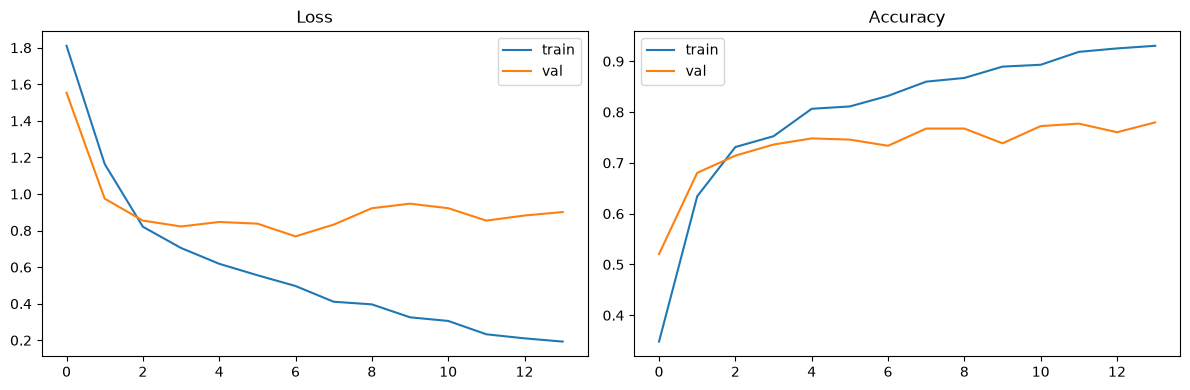

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7346241198964805
                 precision    recall  f1-score   support

        Healthy       0.83      0.86      0.84        90
         Insect       0.76      0.88      0.81        42
     Leaf Scald       0.68      0.62      0.65        63
     Rice Blast       0.91      0.80      0.85       105
Rice Leaffolder       0.72      0.84      0.78        37
   Rice Stripes       0.56      0.50      0.53        40
    Rice Tungro       0.63      0.75      0.68        36

       accuracy                           0.76       413
      macro avg       0.73      0.75      0.73       413
   weighted avg       0.77      0.76      0.76       413

Confusion matrix:
 [[77  5  0  3  0  1  4]
 [ 1 37  2  0  2  0  0]
 [ 0  2 39  2  7  9  4]
 [ 7  1  4 84  2  2  5]
 [ 1  1  1  2 31  1  0]
 [ 2  3 10  1  1 20  3]
 [ 5  0  1  0  0  3 27]]
